# Week 6 — Decision Trees and Random Forests

**Two datasets, one analysis.** This notebook loads the **Credit Risk** (Kaggle, ~29k applications) and
**Statlog German Credit** (UCI, 1,000 applications) datasets together and applies every Week 6
technique to **both**, with matching visualizations, so the two can be compared head to head.
A single tree, the overfitting it causes, and the random-forest fix — on both classification targets.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
sns.set_style('whitegrid'); plt.rcParams['figure.figsize']=(11,4); pd.set_option('display.max_columns',60)
RANDOM_STATE = 42
DATASETS = ['Credit Risk', 'German Credit']
PALETTE = {'Credit Risk':'#4c72b0', 'German Credit':'#55a467'}

# ---------- Credit Risk ----------
def _credit_risk():
    df = pd.read_csv('credit_risk_dataset.csv')
    df = df.dropna(subset=['loan_int_rate']).reset_index(drop=True)
    df = df[df['person_age'] <= 80]
    df = df[df['person_emp_length'].fillna(0) <= 60]
    df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
    df['loan_grade_ord'] = df['loan_grade'].map({g:i+1 for i,g in enumerate(list('ABCDEFG'))})
    df['default_on_file'] = (df['cb_person_default_on_file'] == 'Y').astype(int)
    df['log_income'] = np.log(df['person_income'])
    df = pd.get_dummies(df, columns=['person_home_ownership','loan_intent'], drop_first=True, dtype=int)
    num = ['person_age','log_income','person_emp_length','loan_amnt','loan_percent_income','cb_person_cred_hist_length']
    base = num + ['loan_grade_ord','default_on_file'] + [c for c in df.columns if c.startswith('person_home_ownership_') or c.startswith('loan_intent_')]
    return dict(df=df, num=num, poly=['person_age','loan_amnt','cb_person_cred_hist_length'],
                reg_target='loan_int_rate', reg_label='interest rate (%)', reg_feats=base,
                clf_target='loan_status', clf_pos='default', clf_feats=base+['loan_int_rate'])

# ---------- German Credit ----------
def _german():
    rename={'Attribute1':'checking_status','Attribute2':'duration_months','Attribute3':'credit_history',
     'Attribute4':'purpose','Attribute5':'credit_amount','Attribute6':'savings_status','Attribute7':'employment_since',
     'Attribute8':'installment_rate','Attribute9':'personal_status_sex','Attribute10':'other_debtors',
     'Attribute11':'residence_since','Attribute12':'property','Attribute13':'age_years','Attribute14':'other_installment_plans',
     'Attribute15':'housing','Attribute16':'existing_credits','Attribute17':'job','Attribute18':'num_dependents',
     'Attribute19':'telephone','Attribute20':'foreign_worker','class':'target'}
    df = pd.read_csv('german_credit_data.csv').rename(columns=rename)
    df['bad'] = (df['target'] == 2).astype(int); df = df.drop(columns=['target'])
    df['log_credit_amount'] = np.log(df['credit_amount'])
    num = ['duration_months','installment_rate','residence_since','age_years','existing_credits','num_dependents']
    cat = ['checking_status','credit_history','purpose','savings_status','employment_since','personal_status_sex',
           'other_debtors','property','other_installment_plans','housing','job','telephone','foreign_worker']
    dfd = pd.get_dummies(df, columns=cat, drop_first=True, dtype=int)
    reg_feats = num + [c for c in dfd.columns if any(c.startswith(p+'_') for p in cat)] + ['bad']
    clf_feats = num + ['credit_amount'] + [c for c in dfd.columns if any(c.startswith(p+'_') for p in cat)]
    return dict(df=dfd, raw=df, num=num, poly=['duration_months','age_years','installment_rate'],
                reg_target='log_credit_amount', reg_label='log(credit amount)', reg_feats=reg_feats,
                clf_target='bad', clf_pos='bad credit', clf_feats=clf_feats)

_CACHE = {'Credit Risk':_credit_risk(), 'German Credit':_german()}

def reg_design(name):
    c=_CACHE[name]; X=c['df'][c['reg_feats']].astype(float); y=c['df'][c['reg_target']].astype(float)
    Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.2,random_state=RANDOM_STATE)
    return dict(name=name, Xtr=Xtr,Xte=Xte,ytr=ytr,yte=yte, num=c['num'], poly=c['poly'],
                target=c['reg_target'], label=c['reg_label'], df=c['df'])

def clf_design(name):
    c=_CACHE[name]; X=c['df'][c['clf_feats']].astype(float); y=c['df'][c['clf_target']].astype(int)
    Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.2,random_state=RANDOM_STATE,stratify=y)
    return dict(name=name, Xtr=Xtr,Xte=Xte,ytr=ytr,yte=yte, num=c['num'], pos=c['clf_pos'],
                target=c['clf_target'], df=c['df'])

def rmse(a,b): return float(np.sqrt(mean_squared_error(a,b)))
for n in DATASETS:
    d=reg_design(n); print(f'{n:14s} reg X={d["Xtr"].shape[1]} feats, target={d["target"]}')
    c=clf_design(n); print(f'{n:14s} clf X={c["Xtr"].shape[1]} feats, pos rate={c["ytr"].mean():.3f}')

Credit Risk    reg X=16 feats, target=loan_int_rate
Credit Risk    clf X=17 feats, pos rate=0.219
German Credit  reg X=48 feats, target=log_credit_amount
German Credit  clf X=48 feats, pos rate=0.300


## 1 · A single decision tree overfits as depth grows

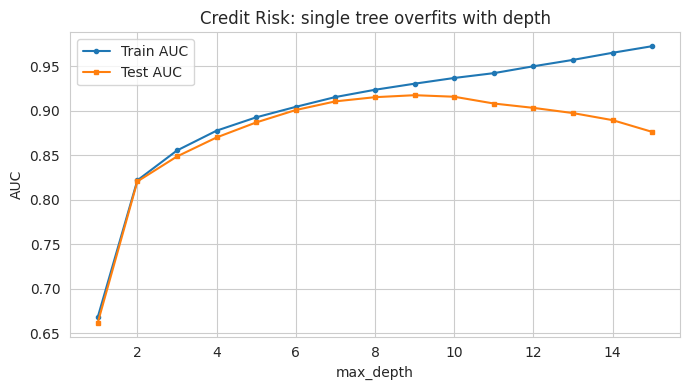

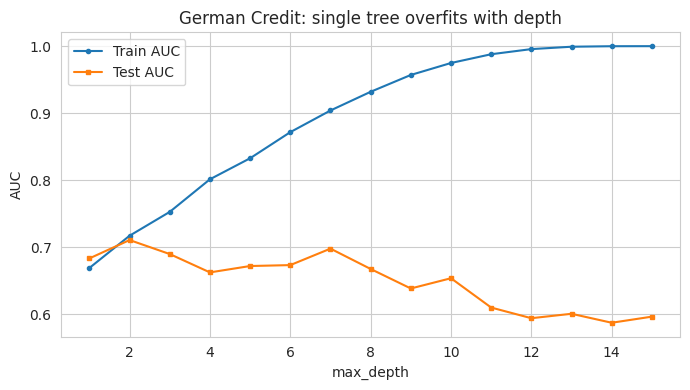

In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score
TREE={}
for name in DATASETS:
    d = clf_design(name); rows=[]
    for dep in range(1,16):
        t=DecisionTreeClassifier(max_depth=dep,random_state=RANDOM_STATE).fit(d['Xtr'],d['ytr'])
        rows.append((dep, roc_auc_score(d['ytr'],t.predict_proba(d['Xtr'])[:,1]), roc_auc_score(d['yte'],t.predict_proba(d['Xte'])[:,1])))
    TREE[name]=dict(d=d)
    dd=[r[0] for r in rows]
    plt.figure(figsize=(7,4)); plt.plot(dd,[r[1] for r in rows],marker='o',ms=3,label='Train AUC'); plt.plot(dd,[r[2] for r in rows],marker='s',ms=3,label='Test AUC')
    plt.xlabel('max_depth'); plt.ylabel('AUC'); plt.title(f'{name}: single tree overfits with depth'); plt.legend(); plt.tight_layout(); plt.show()

## 2 · Random forest and the number of trees

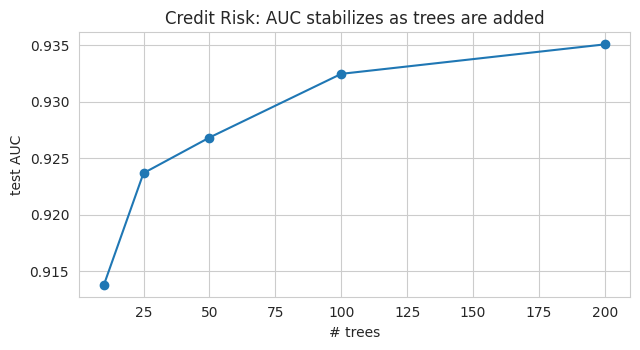

Credit Risk: test AUC with 200 trees = 0.935


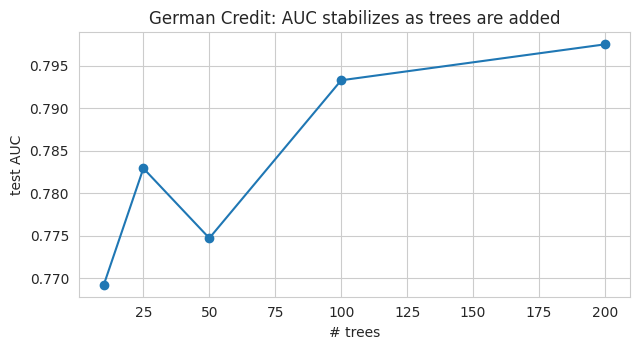

German Credit: test AUC with 200 trees = 0.797


In [3]:
for name in DATASETS:
    d=TREE[name]['d']; ns=[10,25,50,100,200]; au=[]
    for n in ns:
        rf=RandomForestClassifier(n_estimators=n,random_state=RANDOM_STATE,n_jobs=-1).fit(d['Xtr'],d['ytr'])
        au.append(roc_auc_score(d['yte'],rf.predict_proba(d['Xte'])[:,1]))
    plt.figure(figsize=(6.5,3.6)); plt.plot(ns,au,marker='o'); plt.xlabel('# trees'); plt.ylabel('test AUC'); plt.title(f'{name}: AUC stabilizes as trees are added'); plt.tight_layout(); plt.show()
    print(f'{name}: test AUC with 200 trees = {au[-1]:.3f}')

## 3 · Feature importances

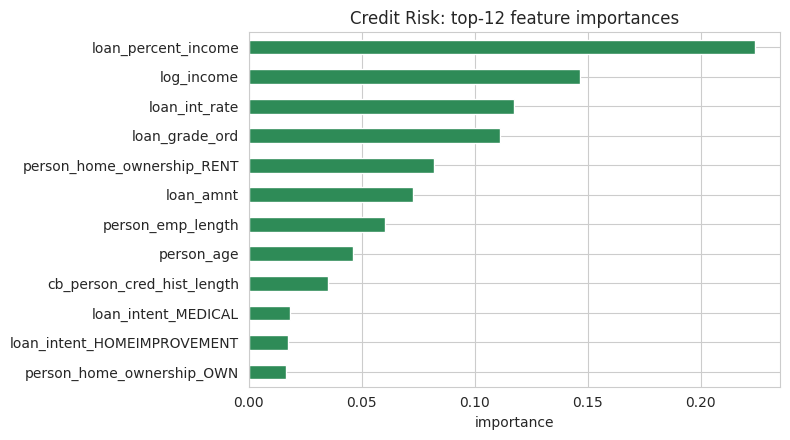

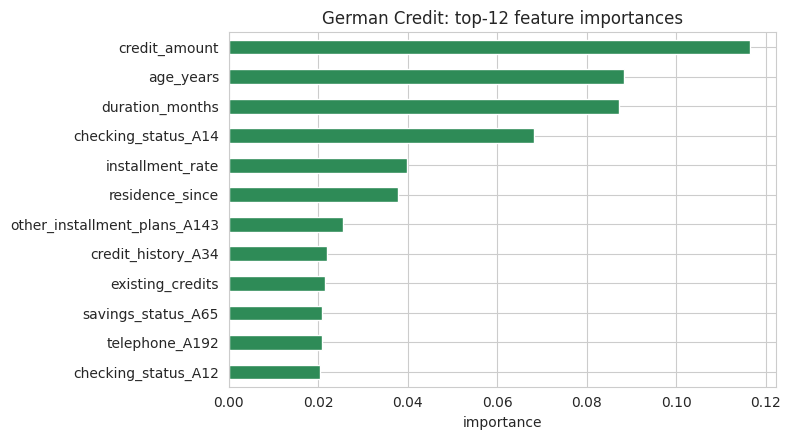

In [4]:
RF={}
for name in DATASETS:
    d=TREE[name]['d']; rf=RandomForestClassifier(n_estimators=200,random_state=RANDOM_STATE,n_jobs=-1).fit(d['Xtr'],d['ytr']); RF[name]=dict(d=d,rf=rf)
    imp=pd.Series(rf.feature_importances_,index=d['Xtr'].columns).sort_values(ascending=False)
    imp.head(12)[::-1].plot(kind='barh',figsize=(8,4.5),color='seagreen'); plt.title(f'{name}: top-12 feature importances'); plt.xlabel('importance'); plt.tight_layout(); plt.show()

## 4 · Cross-validated tuned forest and final comparison

Credit Risk: tuned params {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1} (CV AUC 0.930)


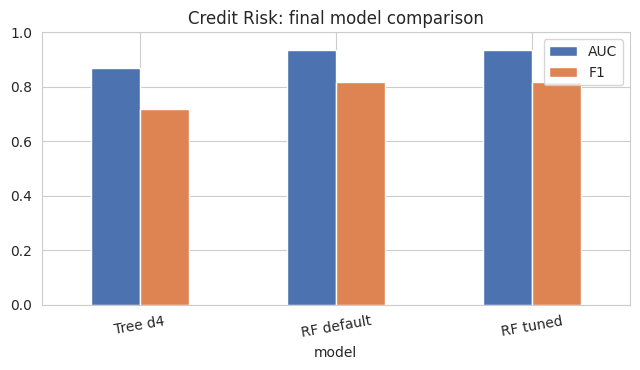

=== Credit Risk ===
                AUC      F1
model                     
Tree d4     0.8699  0.7192
RF default  0.9351  0.8185
RF tuned    0.9351  0.8185 



German Credit: tuned params {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 5} (CV AUC 0.779)


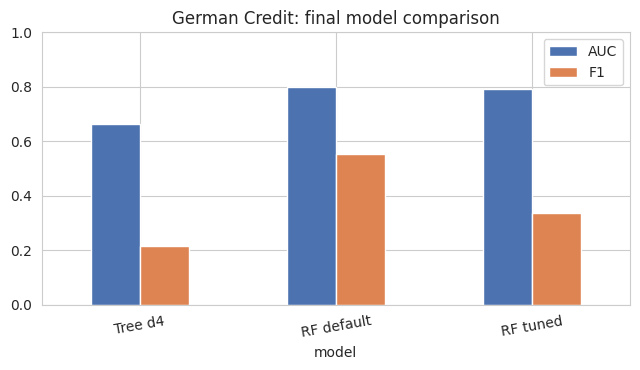

=== German Credit ===
                AUC      F1
model                     
Tree d4     0.6624  0.2143
RF default  0.7975  0.5532
RF tuned    0.7901  0.3377 



In [5]:
FINAL={n:[] for n in DATASETS}
for name in DATASETS:
    d=RF[name]['d']
    g=GridSearchCV(RandomForestClassifier(n_estimators=200,random_state=RANDOM_STATE,n_jobs=-1),
                   {'max_depth':[None,8],'min_samples_leaf':[1,5],'max_features':['sqrt']},
                   scoring='roc_auc',cv=3,n_jobs=-1).fit(d['Xtr'],d['ytr'])
    print(f'{name}: tuned params {g.best_params_} (CV AUC {g.best_score_:.3f})')
    for lbl,m in [('Tree d4',DecisionTreeClassifier(max_depth=4,random_state=RANDOM_STATE).fit(d['Xtr'],d['ytr'])),
                  ('RF default',RF[name]['rf']),('RF tuned',g.best_estimator_)]:
        p=m.predict_proba(d['Xte'])[:,1]; pr=(p>=.5).astype(int)
        FINAL[name].append({'model':lbl,'AUC':round(roc_auc_score(d['yte'],p),4),'F1':round(f1_score(d['yte'],pr),4)})
    fdf=pd.DataFrame(FINAL[name]).set_index('model'); fdf.plot(kind='bar',figsize=(6.5,3.8),color=['#4c72b0','#dd8452']); plt.ylim(0,1); plt.title(f'{name}: final model comparison'); plt.tick_params(axis='x',rotation=10); plt.tight_layout(); plt.show()
    print(f'=== {name} ===\n', fdf, '\n')

## 6 · Conclusions

The overfitting signature is identical on both datasets — a single tree's train AUC climbs toward 1.0 while
test AUC peaks early and falls — and bagging plus feature randomization repairs it in both cases. But the
payoff differs sharply. On **Credit Risk** the forest is the project's best model (test AUC ≈ 0.935), far
ahead of logistic regression, and its importances (loan-to-income, rate, grade, income) match every linear
model. On **German Credit** the forest only reaches AUC ≈ 0.79 — tying, not beating, the logistic model — and
its top features (checking status, credit amount, duration, age) likewise agree with the logistic coefficients.
The tuned forest maximizes CV AUC yet can lower F1 at the fixed 0.5 threshold, a reminder that the operating
threshold matters as much as the model.